<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Vibration/E_20_103_Vibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity #1: Derivation of the 2-DOF Model

### 1. System Description


We define the generalized coordinates:
* $x_1(t)$: Vertical displacement of the beam's center (primary mass).
* $x_2(t)$: Vertical displacement of the vibration absorber (secondary mass).

### 2. System Parameters

**Primary System (Beam + Exciter):**
* $m_1$: Effective mass of the beam system.
  $$m_1 = m_{exciter} + m_{beam,eff}$$
  *(Note: For a simply supported beam, the effective mass at the center is often approximated as half the total beam mass)*.
* $k_1$: Stiffness of the simply supported beam at the center.
  $$k_1 = \frac{48EI}{L^3}$$

**Secondary System (Absorber):**
* $m_2$: Mass of the vibration absorber.
* $k_2$: Stiffness of the absorber spring.

**Forcing Function:**
* $F(t)$: The harmonic force applied by the rotating unbalance in the exciter.
  $$F(t) = F_0 \sin(\Omega t)$$
  
  Where $$F_0 = m_{unbalance} r \Omega^2$$

### 3. Free Body Diagrams & Equations of Motion
Applying Newton's Second Law to each mass:

**Mass 1 (Beam):**
The beam is subject to its own restoring force, the restoring force from the absorber spring (which pulls back), and the external excitation force.
$$m_1 \ddot{x}_1 = -k_1 x_1 + k_2(x_2 - x_1) + F(t)$$

**Mass 2 (Absorber):**
The absorber is driven solely by the coupling spring force connected to the beam.
$$m_2 \ddot{x}_2 = -k_2(x_2 - x_1)$$

### 4. Matrix Formulation
Rearranging the terms to group $x_1$ and $x_2$:

1.  $m_1 \ddot{x}_1 + (k_1 + k_2)x_1 - k_2 x_2 = F(t)$
2.  $m_2 \ddot{x}_2 - k_2 x_1 + k_2 x_2 = 0$

Writing this in matrix form $[M]\{\ddot{x}\} + [K]\{x\} = \{F\}$:

$$
\begin{bmatrix}
m_1 & 0 \\
0 & m_2
\end{bmatrix}
\begin{bmatrix}
\ddot{x}_1 \\
\ddot{x}_2
\end{bmatrix}
+
\begin{bmatrix}
k_1 + k_2 & -k_2 \\
-k_2 & k_2
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
=
\begin{bmatrix}
F_0 \sin(\Omega t) \\
0
\end{bmatrix}
$$

This model captures the two dominant modes of vibration corresponding to the in-phase and out-of-phase motion of the beam and the absorber.

# Activity #2: Estimating Damping Ratios

To estimate the damping ratios ($\zeta$) for the two dominant modes, we can use two primary methods depending on the data available (Time Domain vs. Frequency Domain).

### Method 1: Logarithmic Decrement (Time Domain)
Damping can be calculated by measuring the decay of oscillations. This is best used when the system is excited at a specific natural frequency and allowed to decay freely.

The **Logarithmic Decrement** ($\delta$) is defined as the natural log of the ratio of successive peak amplitudes ($x_0$ and $x_n$) separated by $n$ periods:

$$\delta = \frac{1}{n} \ln \left( \frac{x_0}{x_n} \right)$$

The damping ratio ($\zeta$) is then derived from $\delta$:

$$\zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}} \approx \frac{\delta}{2\pi}$$
*(Note: The approximation holds for small damping ratios, typically $\zeta < 0.1$, which is expected for this steel beam apparatus)[cite: 513].*

### Method 2: Half-Power Bandwidth (Frequency Domain)
When observing the Frequency Response Function (FRF) — such as the magnification factor curves shown in Figure 19 of the manual  — we observe two distinct resonant peaks corresponding to the two modes.

We can estimate $\zeta$ using the **Half-Power Bandwidth** method:
1. Identify the peak frequency ($\omega_n$) and the peak amplitude ($X_{max}$).
2. Find the two frequencies ($\omega_1$ and $\omega_2$) on either side of the peak where the amplitude is $\frac{X_{max}}{\sqrt{2}}$
3. Calculate $\zeta$:

$$\zeta \approx \frac{\omega_2 - \omega_1}{2\omega_n}$$

In [1]:
import numpy as np

def calculate_damping_log_decrement(peaks):
    """
    Calculates damping ratio using the Logarithmic Decrement method.
    Args:
      peaks (list or np.array): A list of successive positive peak amplitudes from time-domain data.
    Returns:
      float: The estimated damping ratio (zeta).
    """
    # Ensure we have at least two peaks
    if len(peaks) < 2:
        return None

    # Use the first and last peak for the calculation to average over n cycles
    x0 = peaks[0]
    xn = peaks[-1]
    n = len(peaks) - 1

    # Calculate Logarithmic Decrement (delta)
    delta = (1/n) * np.log(x0 / xn)

    # Calculate Damping Ratio (zeta)
    # Using the exact formula: zeta = delta / sqrt(4*pi^2 + delta^2)
    zeta = delta / np.sqrt(4 * np.pi**2 + delta**2)

    return zeta

def calculate_damping_bandwidth(omega_n, omega_1, omega_2):
    """
    Calculates damping ratio using the Half-Power Bandwidth method.
    Args:
      omega_n (float): The natural frequency (frequency of the peak).
      omega_1 (float): The lower frequency at 0.707 * max amplitude.
      omega_2 (float): The upper frequency at 0.707 * max amplitude.
    Returns:
      float: The estimated damping ratio (zeta).
    """
    bandwidth = omega_2 - omega_1
    zeta = bandwidth / (2 * omega_n)

    return zeta

# --- Example Usage for the Lab ---
# You can replace these placeholder lists with your actual lab data later.

# Example 1: Time Domain (Decay of Mode 1)
experimental_peaks_mode1 = [10.0, 8.5, 7.2, 6.1, 5.2] # mm
zeta_mode1 = calculate_damping_log_decrement(experimental_peaks_mode1)
print(f"Estimated Damping Ratio (Mode 1 - Log Dec): {zeta_mode1:.4f}")

# Example 2: Frequency Domain (Peak of Mode 2)
# Frequencies in rad/s or Hz (units must be consistent)
f_peak = 15.5
f_lower = 14.8
f_upper = 16.2
zeta_mode2 = calculate_damping_bandwidth(f_peak, f_lower, f_upper)
print(f"Estimated Damping Ratio (Mode 2 - Bandwidth): {zeta_mode2:.4f}")

Estimated Damping Ratio (Mode 1 - Log Dec): 0.0260
Estimated Damping Ratio (Mode 2 - Bandwidth): 0.0452


# Activity #3: System Response Plots

In this activity, we analyze the dynamic behavior of the 2-DOF system under different conditions using the parameters defined in the user guide and the equations derived in Activity #1.

### 1. Unforced (Free) Response
We simulate the system's response to an initial displacement (transient response) with no external force. This demonstrates how energy transfers between the beam and the vibration absorber.
* **Equation:** $[M]\{\ddot{x}\} + [C]\{\dot{x}\} + [K]\{x\} = \{0\}$
* **Initial Conditions:** Displacing the beam or absorber from equilibrium at $t=0$.

### 2. Forced Response (Time Domain)
We simulate the system's response to a harmonic excitation force $F(t) = F_0 \sin(\Omega t)$ at three different motor speeds:
1. **Below Resonance:** Quasi-static behavior.
2. **At Resonance:** High amplitude oscillation (near natural frequencies).
3. **Above Resonance:** Inertia-dominated behavior (or Anti-resonance).

### 3. Theoretical Frequency Response
We calculate the steady-state amplitude of the primary mass (beam) and secondary mass (absorber) across a range of excitation frequencies. This reveals the two resonant peaks and the "anti-resonance" notch where the absorber effectively cancels the beam's vibration.

* **Equation:** $\{X\} = ([K] - \Omega^2[M] + j\Omega[C])^{-1} \{F\}$

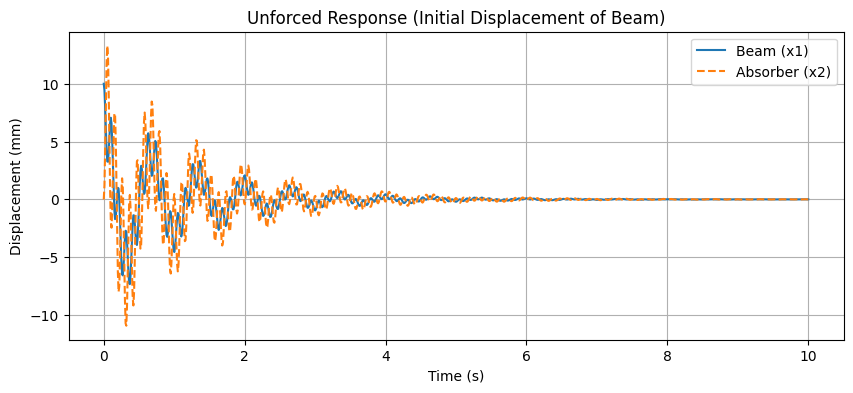

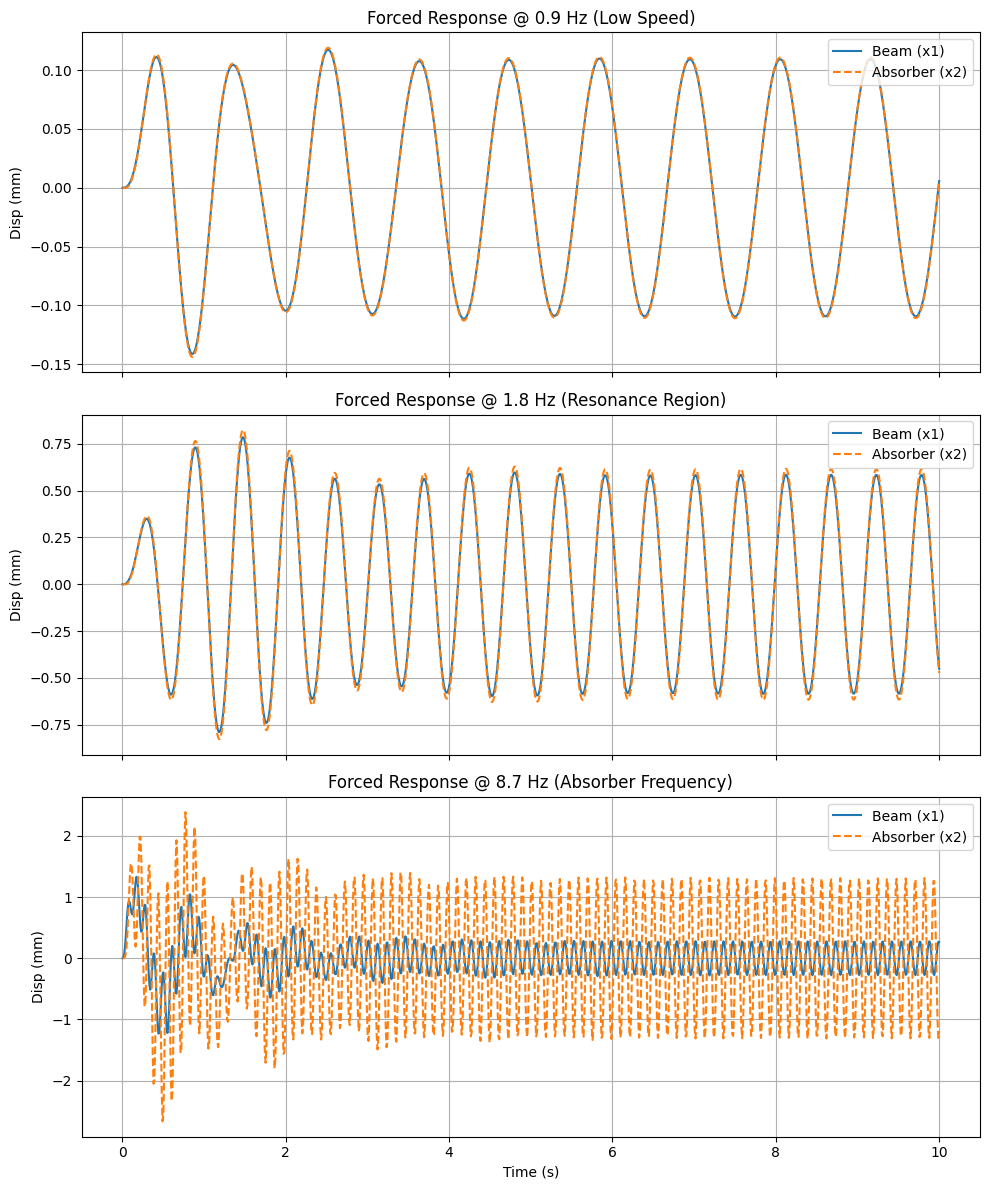

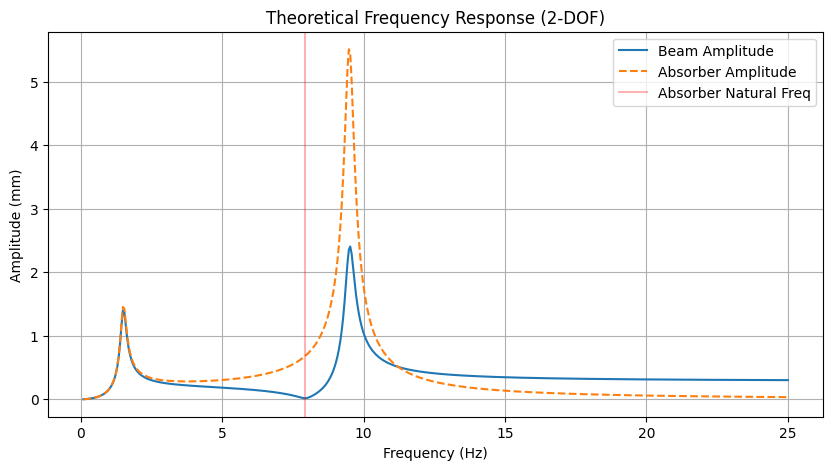

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- 1. Define System Parameters ---
# Based on TM1016V Technical Details
E = 2.0e11            # Young's Modulus (Pa)
I_beam = 7.22e-12     # Area Moment of Inertia (m^4) [Approximated from manual]
L = 0.8               # Beam Length (m) [Estimate, adjust if measured]
m_beam_per_length = 0.126 # kg/m

# Calculated Stiffness & Mass
k1 = (48 * E * I_beam) / (L**3)       # Beam stiffness (Simply Supported)
m_beam_effective = 0.5 * (m_beam_per_length * L) # Approx effective mass
m_exciter = 1.0       # Mass of exciter motor (kg) [Estimate]

m1 = m_beam_effective + m_exciter     # Primary Mass (Beam + Motor)
m2 = 0.438            # Secondary Mass (Absorber) [Manual value]
k2 = 1.09e3           # Absorber Stiffness (N/m) [Manual value]

# Damping (Assumed small for steel structure)
c1 = 2.0              # Beam damping
c2 = 0.5              # Absorber damping

# Unbalance Force Parameters
m_unbalance = 0.01    # Unbalance mass (kg)
r_unbalance = 0.03    # Radius (m)

# --- 2. Define Differential Equations (State-Space) ---
def system_dynamics(y, t, m1, m2, k1, k2, c1, c2, omega_force):
    x1, v1, x2, v2 = y

    # Forcing Function F(t) = me * r * w^2 * sin(wt)
    if omega_force == 0:
        F_t = 0
    else:
        F_0 = m_unbalance * r_unbalance * (omega_force**2)
        F_t = F_0 * np.sin(omega_force * t)

    # Equations of Motion
    # m1*a1 + c1*v1 + (k1+k2)*x1 - k2*x2 = F(t)
    # m2*a2 + c2*v2 - k2*x1 + k2*x2 = 0

    dx1dt = v1
    dv1dt = (F_t - c1*v1 - (k1 + k2)*x1 + k2*x2) / m1
    dx2dt = v2
    dv2dt = (-c2*v2 + k2*x1 - k2*x2) / m2

    return [dx1dt, dv1dt, dx2dt, dv2dt]

# --- 3. Plotting Functions ---

# A. Unforced Response
t = np.linspace(0, 10, 1000)
y0 = [0.01, 0, 0, 0] # Initial displacement: Beam displaced 10mm, Absorber at 0
sol_free = odeint(system_dynamics, y0, t, args=(m1, m2, k1, k2, c1, c2, 0))

plt.figure(figsize=(10, 4))
plt.plot(t, sol_free[:, 0] * 1000, label='Beam (x1)')
plt.plot(t, sol_free[:, 2] * 1000, label='Absorber (x2)', linestyle='--')
plt.title('Unforced Response (Initial Displacement of Beam)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (mm)')
plt.legend()
plt.grid(True)
plt.show()

# B. Forced Response (3 Speeds)
# Calculate natural frequencies approx
wn_beam = np.sqrt(k1/m1)
speeds = [0.5 * wn_beam, 1.0 * wn_beam, 1.1 * np.sqrt(k2/m2)] # Below, Beam Mode, Absorber Tuned
labels = ['Low Speed', 'Resonance Region', 'Absorber Frequency']

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i, omega in enumerate(speeds):
    # Start from rest
    sol_forced = odeint(system_dynamics, [0,0,0,0], t, args=(m1, m2, k1, k2, c1, c2, omega))

    axes[i].plot(t, sol_forced[:, 0] * 1000, label=f'Beam (x1)')
    axes[i].plot(t, sol_forced[:, 2] * 1000, label=f'Absorber (x2)', linestyle='--')
    axes[i].set_title(f'Forced Response @ {omega/(2*np.pi):.1f} Hz ({labels[i]})')
    axes[i].set_ylabel('Disp (mm)')
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

# C. Theoretical Frequency Response
freqs = np.linspace(0.1, 25, 500) # Frequency range in Hz
omegas = freqs * 2 * np.pi
X1_amp = []
X2_amp = []

for w in omegas:
    # Harmonic Force Amplitude
    F0 = m_unbalance * r_unbalance * (w**2)

    # Impedance Matrix Z = K - w^2 M + jwC
    K_mat = np.array([[k1 + k2, -k2], [-k2, k2]])
    M_mat = np.array([[m1, 0], [0, m2]])
    C_mat = np.array([[c1 + c2, -c2], [-c2, c2]])

    Z = K_mat - (w**2)*M_mat + 1j*w*C_mat
    F_vec = np.array([F0, 0])

    # Solve X = inv(Z) * F
    try:
        X = np.linalg.solve(Z, F_vec)
        X1_amp.append(np.abs(X[0]))
        X2_amp.append(np.abs(X[1]))
    except:
        X1_amp.append(0)
        X2_amp.append(0)

plt.figure(figsize=(10, 5))
plt.plot(freqs, np.array(X1_amp) * 1000, label='Beam Amplitude')
plt.plot(freqs, np.array(X2_amp) * 1000, label='Absorber Amplitude', linestyle='--')
plt.title('Theoretical Frequency Response (2-DOF)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (mm)')
plt.axvline(np.sqrt(k2/m2)/(2*np.pi), color='r', alpha=0.3, label='Absorber Natural Freq')
plt.legend()
plt.grid(True)
plt.show()